# Data Analysis

# Clinic 3: Classification with missing values & inbalanced data

## DELIVERABLES (DEADLINE 06/Mar late night, wildcards possible)

Instructions for the deliverable: 

* Make sure that you include a proper amount/mix of comments, results and code.

* In the end, make sure that all cells are executed properly and everything you need to show is in your (execucted) notebook.

* You are asked to deliver **only your executed notebook file, .ipnyb** and nothing else. Enjoy!

* The second part of the assignment is purposefully left open-ended.

## Score breakdown

Question | Points
--- | ---
[Question 1](#q1) | 3
[Question 2](#q2) | 6
[Question 3](#q3) | 3
[Question 4](#q4) | 4
[Question 5](#q5) | 4
[Question 6](#q6) | 6
[Question 7](#q7) | 6
[Question 8](#q8) | 4
[Question 9](#q9) | 6
[Question 10](#q10)| 18
Total | 60

This score will be scaled down to 1 and that will be your final clinic score.

## Learning Goals

By the end of this clinic, you should be able to:

- Build classification models for credit default prediction
- Quantify and handle class imbalance
- Understand why accuracy fails in imbalanced settings
- Compare:
  - Accuracy
  - ROC-AUC
  - Precision-Recall AUC
  - Confusion matrices
- Use:
  - Cross-validation
  - Regularization
  - Class weighting
  - Threshold tuning

# 0. The dataset

### What is LendingClub?

LendingClub is a peer-to-peer lending platform that connects borrowers with investors. Instead of borrowing from a traditional bank, individuals apply for loans through the platform. Investors then fund these loans and receive returns if borrowers repay successfully.

The dataset used in this clinic contains historical loan data, including:

- Borrower characteristics
- Loan characteristics
- Credit risk indicators
- Loan repayment outcomes

Our goal is to predict whether a loan will **default**.

---

### What is the Prediction Task?

We focus on a binary classification problem:

- `default = 1` → Loan was **Charged Off** (borrower failed to repay)
- `default = 0` → Loan was **Fully Paid**

This is a classic **credit risk modeling** problem.

It is also a naturally **imbalanced dataset**, since most borrowers repay their loans.

### Structure of the Dataset

The dataset contains several categories of variables.

---

### 1️⃣ Borrower Employment & Income Information

- `emp_title` – Job title of the borrower  
- `emp_length` – Length of employment (in years)
- `annual_income` – Borrower’s reported annual income (in USD)
- `verified_income` – Whether income was verified (yes/no)
- `annual_income_joint` – Joint annual income (if co-borrower e.g. for couples)  
- `verification_income_joint` – Whether joint income was verified  
---

### 2️⃣ Housing & Application Information

- `state` – U.S. state of residence
- `homeownership` – three options: RENT / OWN / MORTGAGE  
- `application_type` – Individual or joint application  
- `loan_purpose` – Purpose of the loan (e.g., debt consolidation, credit card, car)  
---

### 3️⃣ Debt & Financial Burden Measures

- `debt_to_income` – Debt-to-income ratio
- `debt_to_income_joint` – Joint DTI (if applicable)  
- `installment` – Monthly loan payment (in USD)
- `loan_amount` – Total loan amount requested (in USD)
- `term` – Loan duration (in months)
- `interest_rate` – Interest rate assigned to the loan (in %)
---

### 4️⃣ Credit History Indicators

- `earliest_credit_line` – Year of first credit line  
- `delinq_2y` – Delinquencies in past 2 years (*delinquency* means failure to fulfill a financial obligation)
- `inquiries_last_12m` – Credit inquiries in last 12 months  
- `months_since_last_delinq` - months since ast delinquency 
- `months_since_90d_late` - a 90-day delinquency is a serious milestone in credit reporting
- `num_accounts_30d_past_due` - number of accounts that are 30 days past due
- `num_accounts_120d_past_due` - number of accounts that are 120 days past due
- `current_accounts_delinq` - number of accounts in delinquency
- `num_historical_failed_to_pay` - times that failed a payment in the past
- `public_record_bankrupt` - whether exists a public record for bankruptcy
- `tax_liens` - yes/no: a lien is a legal claim placed by some authority (usually public) against a person’s property 
---

### 5️⃣ Credit Utilization & Account Structure

- `total_credit_lines` - # of credit lines
- `open_credit_lines` - # of open credit ines
- `total_credit_limit` - credit limit (in USD)
- `total_credit_utilized` - credit used (in USD)
- `account_never_delinq_percent` - %
- `num_satisfactory_accounts` - # of accounts
- `num_open_cc_accounts` - # of accounts
- `num_cc_carrying_balance` - # credit cards carrying balance
- `num_active_debit_accounts` - # of accounts
- `total_debit_limit` - debit limit (in USD)
- `num_mort_accounts` - # of mortgage accounts
- `accounts_opened_24m` - # of accounts opened in the last 24 months
---

### 6️⃣ LendingClub Risk Grades

- `grade` – Risk category (A–G), internal assessment by LendingClub
- `sub_grade` – More granular risk classification, also by LendingClub
---

### 7️⃣ Loan Outcome Variables

- `balance` – Remaining balance  (in USD)
- `paid_total` – Total amount paid (in USD)
- `paid_principal` – Principal repaid (in USD)
- `paid_interest` – Interest paid (in USD)
- `paid_late_fees` – Late fees paid (in USD)
- `issue_month` – month/year of issue
- `initial_listing_status` – whole or functional  
- `disbursement_method` – How funds were disbursed 

- `default` – Final loan outcome (0 or 1) This is our prediction variable.

In [3]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS
#from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
%matplotlib inline
import seaborn as sns
sns.set(context='paper')

In [5]:
# Load the loans dataset
loans = pd.read_csv('loans_full_schemaa.csv')

# Display basic information about the dataset
print(f"Dataset shape: {loans.shape}")
loans.head()

Dataset shape: (10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees,default
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar/18,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0,0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb/18,whole,Cash,4651.37,499.12,348.63,150.49,0.0,0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb/18,fractional,Cash,1824.63,281.80,175.37,106.43,0.0,0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan/18,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0,0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar/18,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0,1


In [6]:
# Display column names and data types
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

## Part 1: Pre-processing

Before building any model, remove variables that would not have been known at the time the loan *was issued*. Using post-outcome information is called **data leakage** (which we covered in class) and leads to unrealistically high performance.

### Question 1: Data leakage

1. Which variables in this dataset must be excluded due to data leakage?
2. Why are they invalid predictors?
3. What would happen to model performance if you kept them?
4. Write code that would remove the variables from the dataframe.

Hint: Look for variables that describe repayment amounts, balances, late fees, or the final loan outcome.


**Your answer goes here**

In [7]:
###incude code where you remove the variabes causing the leakage
# Identify variables that cause data leakage
leakage_columns = [
    'balance',
    'paid_total',
    'paid_principal',
    'paid_interest',
    'paid_late_fees'
]

# Remove leakage variables from the dataset
loans = loans.drop(columns=leakage_columns, errors='ignore')

# Verify removal
print("Remaining columns:", loans.shape[1])
print("Removed columns:", leakage_columns)

Remaining columns: 50
Removed columns: ['balance', 'paid_total', 'paid_principal', 'paid_interest', 'paid_late_fees']


### Question 1 Explanation – Data Leakage

Data leakage occurs when the model uses information that would not have been available at the time a prediction is made. In this dataset, the goal is to predict whether a loan will default. Therefore, any variable that describes repayment outcomes or loan balances after the loan has already been issued must be removed.

The following variables cause data leakage:

- `balance`
- `paid_total`
- `paid_principal`
- `paid_interest`
- `paid_late_fees`

These variables contain information about how much the borrower has already repaid or still owes. This information only becomes available after the loan has been issued and payments have begun. Therefore, they cannot be used as predictors when building a model that predicts default at the time of loan approval.

If these variables were kept in the dataset, the model would indirectly observe the outcome it is trying to predict. For example, borrowers who have already repaid a large amount are unlikely to default, while borrowers who have paid little may be more likely to default. As a result, the model would achieve unrealistically high performance because it would be using future information.

This phenomenon is known as **data leakage**, and it leads to overly optimistic evaluation results that would not generalize to real-world predictions.

### Question 2: Analyze Missing Values

Now that we got rid of the "leakage" variables, it's important to understand the extent and pattern of missing data in the dataset.

1. Calculate the percentage of missing values for each column in the dataset.
2. Identify the top 10 columns with the highest percentage of missing values.
3. Create a proper visualization (bar plot or other) showing missing value patterns. We give bonus points if you come up with a suitable visualization going beyond the standard (which is still perfcetly fine)

Afterwards, discuss:

4. Which variables have substantial missingness (>20%)?

5. Are there any patterns in the missingness that could be informative (refer to the MAR, MNAR, MCAR concepts from week 1)?

6. How might you handle these missing values in your modeling pipeline? Implement some function to handle it on your dataframe.

7. Could the missingness itself be informative? (e.g., missing employment length might indicate self-employment)

In [8]:
# Your code here: Calculate and visualize missing values
#####################
# Hint: Use .isnull().sum() and .isnull().mean() * 100
#####################

# 1. Calculate missing values
missing_counts = loans.isnull().sum()
missing_percentages = loans.isnull().mean() * 100

missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percentages
}).sort_values('missing_percent', ascending=False)

print(f"\nTotal number of rows: {len(loans)}")
print(f"Total number of columns: {len(loans.columns)}")
print(f"\nColumns with missing values: {(missing_counts > 0).sum()}")
print(f"Columns with NO missing values: {(missing_counts == 0).sum()}")


Total number of rows: 10000
Total number of columns: 50

Columns with missing values: 10
Columns with NO missing values: 40


In [9]:
# 2. Identify the top 10 columns with highest missing percentages
top_10_missing = missing_df.head(10)

print("\nTop 10 columns with highest missing values:")
print(top_10_missing)


Top 10 columns with highest missing values:
                                  missing_count  missing_percent
verification_income_joint                  8545            85.45
annual_income_joint                        8505            85.05
debt_to_income_joint                       8505            85.05
months_since_90d_late                      7715            77.15
months_since_last_delinq                   5658            56.58
months_since_last_credit_inquiry           1271            12.71
emp_title                                   833             8.33
emp_length                                  817             8.17
num_accounts_120d_past_due                  318             3.18
debt_to_income                               24             0.24


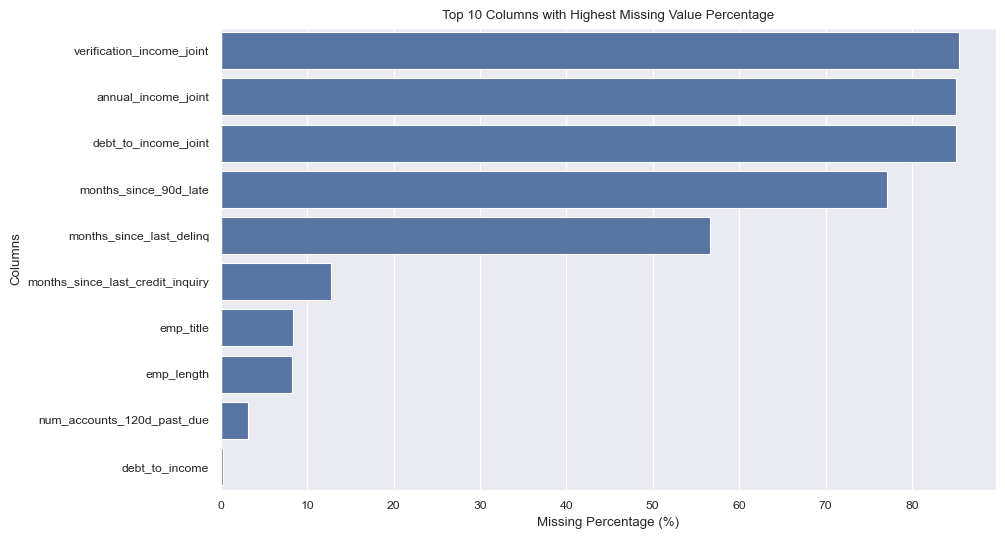

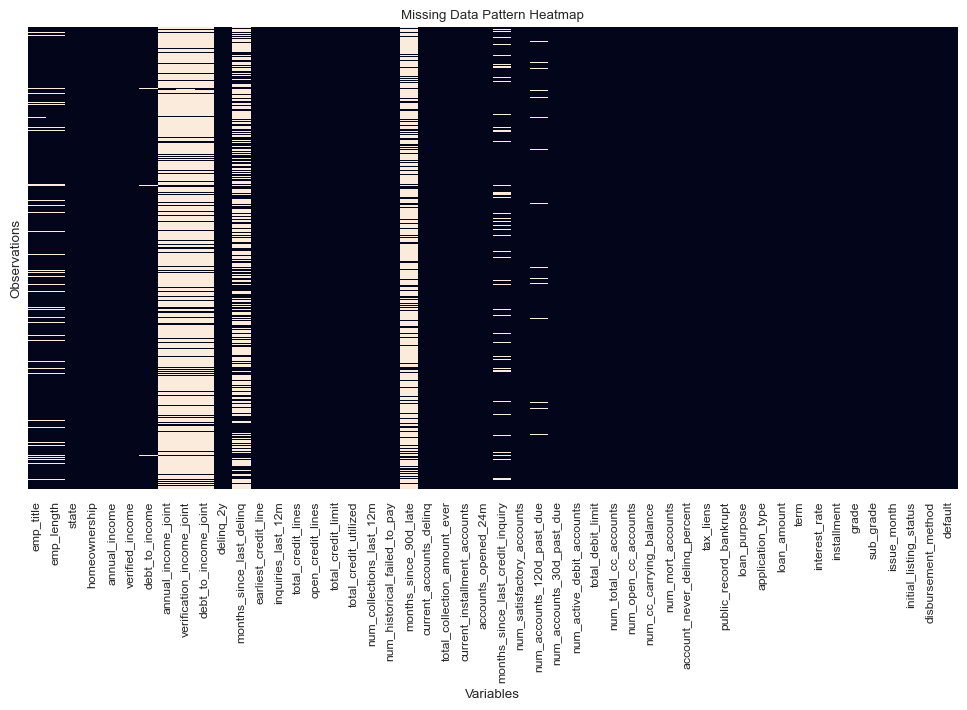

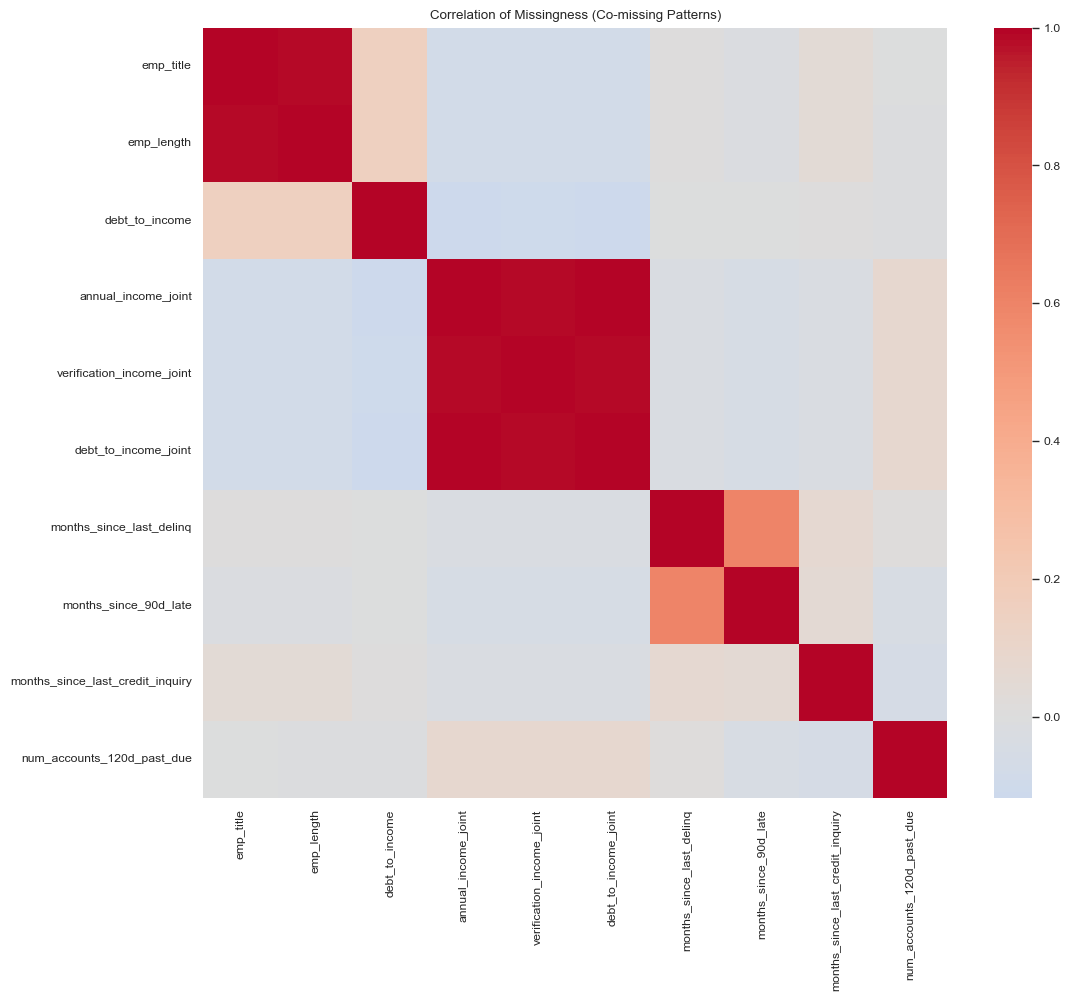

In [17]:
# 3. Create visualization showing missing value patterns
# ================================
# Visualization 1 — Bar plot (standard)
# ================================

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_10_missing['missing_percent'],
    y=top_10_missing.index
)

plt.title("Top 10 Columns with Highest Missing Value Percentage")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Columns")
plt.show()


# ================================
# Visualization 2 — Missingness Heatmap (Bonus)
# ================================
plt.figure(figsize=(12,6))

sns.heatmap(
    loans.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Data Pattern Heatmap")
plt.xlabel("Variables")
plt.ylabel("Observations")

plt.show()


# Correlation of missingness (which columns tend to be missing together)
miss = loans.isnull().astype(int)
cols_with_missing = miss.columns[miss.sum() > 0]  # only columns that have any missing

miss_corr = miss[cols_with_missing].corr()

plt.figure(figsize=(12,10))
sns.heatmap(miss_corr, center=0, cmap="coolwarm")
plt.title("Correlation of Missingness (Co-missing Patterns)")
plt.show()

**Your answer goes here**

In [13]:
#here incude code to handle the missing values
# ================================
# Function to handle missing values
# ================================

def handle_missing_values(df):
    df_clean = df.copy()

    # Separate numeric and categorical columns
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    categorical_cols = df_clean.select_dtypes(exclude=[np.number]).columns

    # Numeric: fill with median
    for col in numeric_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # Categorical: fill with mode (most frequent)
    for col in categorical_cols:
        # mode() can return multiple values; take the first
        mode_val = df_clean[col].mode(dropna=True)
        fill_val = mode_val.iloc[0] if len(mode_val) > 0 else "Unknown"
        df_clean[col] = df_clean[col].fillna(fill_val)

    return df_clean


# Apply and verify
loans_clean = handle_missing_values(loans)
print("Remaining missing values:", loans_clean.isnull().sum().sum())

Remaining missing values: 0


### Question 2 Explanation – Missing Value Analysis

After removing the leakage variables, we analyzed the extent of missing values across the dataset.

First, we calculated the percentage of missing values for each column and identified the top 10 variables with the highest missing percentages. The visualization highlights which variables contain substantial missingness and therefore may require special handling before modeling.

Variables with more than **20% missing values** can be considered to have substantial missingness. These variables may require either imputation strategies or removal depending on their importance and predictive value.

### Missingness Patterns

Missing data can generally fall into three categories:

- **MCAR (Missing Completely at Random):** Missingness is unrelated to any other variables or the missing value itself.
- **MAR (Missing at Random):** Missingness depends on other observed variables.
- **MNAR (Missing Not at Random):** Missingness depends on the value that is missing itself.

In this dataset, several missing patterns appear to follow the **MAR mechanism**. For example, variables related to joint income (`annual_income_joint`, `verification_income_joint`) are often missing when the application type is individual rather than joint. This means the missingness is dependent on another observed variable.

Some missingness may also be **informative**. For instance, missing employment length (`emp_length`) could indicate self-employment, irregular employment, or borrowers who chose not to disclose their job history. In such cases, the missingness itself may contain useful information about borrower risk.

### Handling Missing Values

For the modeling pipeline, we implemented a simple imputation strategy:

- **Numerical variables:** missing values replaced with the median.
- **Categorical variables:** missing values replaced with the mode.

Median imputation is robust to outliers and is commonly used in financial datasets. Mode imputation allows categorical variables to retain their most common category without introducing unrealistic values.

More advanced strategies could include model-based imputation or adding indicator variables to capture whether a value was originally missing.

### Question 3: Quantify the Imbalance

We now focus on the binary variable `default`, which is the one we want to predict.

1. Compute the percentage of:
   - Defaulted loans 
   - Fully paid loans 
2. Which class is the majority?
3. Which class is the minority?
4. What would be the accuracy of a classifier that predicts all loans as Fully Paid?
5. Make an appropriate plot to show the class imbalance

In [18]:
#your code here
# ================================
# Question 3: Class Imbalance Analysis
# ================================

# Count class distribution
class_counts = loans['default'].value_counts()

print("Class distribution:")
print(class_counts)

# Calculate percentages
class_percentages = loans['default'].value_counts(normalize=True) * 100

print("\nClass percentages:")
print(class_percentages)

# Identify majority and minority class
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

print("\nMajority class:", majority_class)
print("Minority class:", minority_class)

# Baseline accuracy if predicting majority class
baseline_accuracy = class_percentages.max()

print(f"\nBaseline accuracy (always predicting majority class): {baseline_accuracy:.2f}%")

Class distribution:
default
0    9800
1     200
Name: count, dtype: int64

Class percentages:
default
0    98.0
1     2.0
Name: proportion, dtype: float64

Majority class: 0
Minority class: 1

Baseline accuracy (always predicting majority class): 98.00%


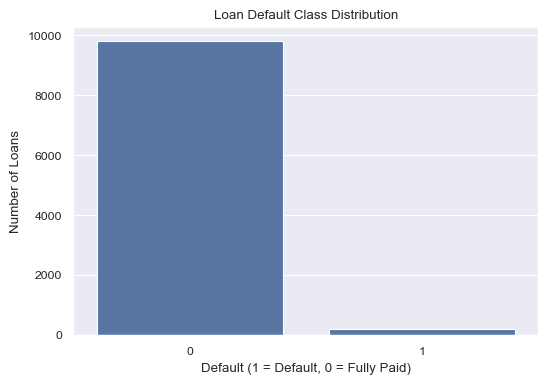

In [21]:
# Visualization: Class Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='default', data=loans)

plt.title("Loan Default Class Distribution")
plt.xlabel("Default (1 = Default, 0 = Fully Paid)")
plt.ylabel("Number of Loans")

plt.show()

**Your answer goes here**
### Question 3 Explanation – Class Imbalance

To understand the class distribution of the target variable, we analyzed the number of loans that defaulted versus those that were fully paid.

The results show that the dataset is **imbalanced**, meaning that one class appears much more frequently than the other. In most lending datasets, the majority of loans are fully repaid while only a smaller portion of loans default.

This imbalance has important implications for model evaluation. If a classifier simply predicted the majority class for every observation (for example predicting that every borrower will repay the loan), it would still achieve relatively high accuracy.

The baseline accuracy of such a naive classifier is equal to the percentage of the majority class in the dataset.

However, this model would be useless in practice because it would fail to identify borrowers who are actually likely to default. Since detecting risky borrowers is the primary goal in credit risk modeling, relying on accuracy alone would be misleading.

Therefore, more informative metrics such as **precision, recall, F1-score, ROC-AUC, or cost-based evaluation** are required when dealing with imbalanced classification problems.

### Question 4: Why Accuracy Fails

1. Why is accuracy not an appropriate metric in this dataset?
2. In credit lending, we assume that the cost of missing a default (i.e. lose an entire loan because a bad decision to hand out the loan was made) is approx. and on average 10,000 USD and the cost of rejecting a good borrower (i.e. the lost profit for rejecting a loan that would pay in ful) is 500 USD. Which is more costly:

   - A False Negative (missed defaulter)?
   - A False Positive (rejected good borrower)?
   
   Support your conclusions with calculations and plots.
   
3. Which metric would better reflect business risk?

**Your answer goes here**

In [24]:
#calculations for the cost
# ================================
# Question 4: Why Accuracy Fails
# ================================

# Business cost assumptions
cost_false_negative = 10000   # giving loan to someone who defaults
cost_false_positive = 500     # rejecting a borrower who would repay

print("Cost of False Negative (missed defaulter): $", cost_false_negative)
print("Cost of False Positive (rejecting good borrower): $", cost_false_positive)

# Compare cost ratio
cost_ratio = cost_false_negative / cost_false_positive

print("\nA False Negative is", cost_ratio, "times more expensive than a False Positive.")

# Example cost impact using current class distribution

default_count = loans['default'].sum()
non_default_count = len(loans) - default_count

total_cost_FN = default_count * cost_false_negative
total_cost_FP = non_default_count * cost_false_positive

print("If we miss all defaulters, potential loss:", total_cost_FN)
print("If we reject all good borrowers, opportunity loss:", total_cost_FP)

#ideas: consider the amounts of FP and FN (given the dataset) or even extreme classifiers (e.g. giving all loans)

Cost of False Negative (missed defaulter): $ 10000
Cost of False Positive (rejecting good borrower): $ 500

A False Negative is 20.0 times more expensive than a False Positive.
If we miss all defaulters, potential loss: 2000000
If we reject all good borrowers, opportunity loss: 4900000


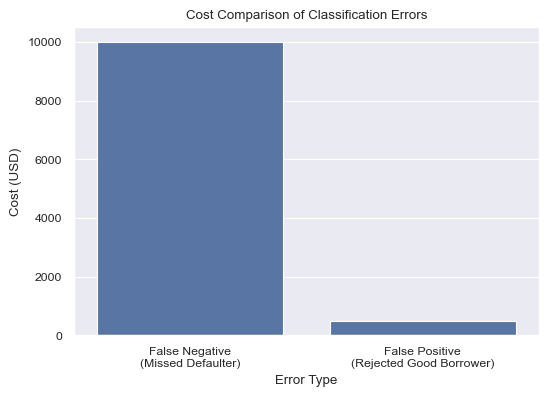

In [23]:
# Visualizing cost difference

costs = {
    "False Negative\n(Missed Defaulter)": cost_false_negative,
    "False Positive\n(Rejected Good Borrower)": cost_false_positive
}

plt.figure(figsize=(6,4))

sns.barplot(
    x=list(costs.keys()),
    y=list(costs.values())
)

plt.title("Cost Comparison of Classification Errors")
plt.ylabel("Cost (USD)")
plt.xlabel("Error Type")

plt.show()

**Your answer goes here**

### Question 4 Explanation – Why Accuracy Fails

Accuracy is not an appropriate metric in this dataset because the classification problem has **highly asymmetric costs**.

In credit lending, two types of errors can occur:

**False Negative (FN):**  
A borrower who will default is predicted as safe and receives the loan.

**False Positive (FP):**  
A borrower who would repay the loan is rejected.

According to the business assumptions:

- $C_{FN} = 10{,}000$ USD (the lender loses most of the loan)  
- $C_{FP} = 500$ USD (lost profit opportunity)

This means that a **False Negative is 20 times more costly than a False Positive**.

Because of this cost imbalance, accuracy becomes misleading. A model could achieve high accuracy by predicting most borrowers as safe, but it would still fail to identify risky borrowers. Missing even a small number of defaulters can generate very large financial losses.

Therefore, evaluation metrics should focus on detecting defaults rather than simply maximizing overall accuracy.

Metrics that better reflect business risk include:

- **Recall (Sensitivity)** for the default class
- **Precision**
- **F1-score**
- **ROC-AUC**
- **Cost-based evaluation metrics**

In particular, **recall for defaulters** is important because it measures how well the model identifies borrowers who are likely to default, which directly reduces financial loss for the lender.

### Question 5: Identify Valid Features

1. We are now considering the rest of the features (after removing leakage variables).

   Identify which features are:
   - Numerical?
   - Categorical?
   - Ordinal?

2. Which categorical variables need encoding?

3. Are there any variabes with high cardinality (i.e. high number of categories) that you woud consider removing?

In [26]:
# Your code here: (if needed)
# ================================
# Question 5: Identify Feature Types
# ================================

# Identify numerical and categorical variables using pandas
numerical_features = loans.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = loans.select_dtypes(include=['object']).columns.tolist()

# Identify cardinality of categorical variables
cardinality = loans[categorical_features].nunique().sort_values(ascending=False)

# Define high cardinality threshold (commonly >50 unique values)
high_cardinality = cardinality[cardinality > 50]

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nCategorical feature cardinality:")
print(cardinality)

print("\nHigh cardinality variables:")
print(high_cardinality)

Number of numerical features: 38
Number of categorical features: 12

Numerical features:
['emp_length', 'annual_income', 'debt_to_income', 'annual_income_joint', 'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq', 'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines', 'total_credit_limit', 'total_credit_utilized', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'months_since_90d_late', 'current_accounts_delinq', 'total_collection_amount_ever', 'current_installment_accounts', 'accounts_opened_24m', 'months_since_last_credit_inquiry', 'num_satisfactory_accounts', 'num_accounts_120d_past_due', 'num_accounts_30d_past_due', 'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts', 'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt', 'loan_amount', 'term', 'interest_rate', 'installment', 'default']

Categorical features:
['emp_t

**Your answer goes here**
### Question 5 Explanation – Identifying Valid Features

After removing leakage variables, the remaining features were categorized based on their data types and their role in modeling.

#### Numerical Variables

Numerical variables represent continuous or count-based financial and credit metrics. Examples include:

- `annual_income`
- `loan_amount`
- `interest_rate`
- `installment`
- `debt_to_income`
- `total_credit_limit`
- `total_credit_utilized`
- `open_credit_lines`
- `accounts_opened_24m`

These variables can generally be used directly in machine learning models after handling missing values.

#### Categorical Variables

Categorical variables represent discrete categories and therefore require encoding before being used in most machine learning algorithms. Examples include:

- `homeownership`
- `verified_income`
- `state`
- `loan_purpose`
- `application_type`
- `initial_listing_status`
- `disbursement_method`

These variables would typically be encoded using **one-hot encoding**.

#### Ordinal Variables

Some categorical variables have an inherent ordering:

- `grade` (A–G risk categories)
- `sub_grade` (A1–G5 finer risk classification)
- `emp_length` (employment length categories)

Because these variables have an order, they could be encoded using **ordinal encoding** rather than one-hot encoding.

#### High Cardinality Variables

Some categorical variables may contain a very large number of unique values. In particular:

- `emp_title`

Job titles often contain hundreds or thousands of unique values. Such high cardinality variables can increase model complexity and introduce noise, making them difficult to encode effectively. Therefore, it may be reasonable to remove or simplify this variable before modeling.

#### Encoding Considerations

Before building a model, categorical variables must be converted into numerical representations. Common approaches include:

- **One-hot encoding** for nominal categorical variables
- **Ordinal encoding** for ordered categories
- Removing or grouping **high-cardinality variables** that provide limited predictive value.

## Part 2: Fit a logistic model ignoring missing values

Now by this point, we assume that you have dealt with missing values, possible data leakage and have done some first pre-processing decisions. Feel free to continue the exploration here, but keep in ind that Questions 6-8 are still informative (we don't care about performance yet). You will explore an open model in Question 10.

### Question 6: Logistic Regression (Baseline)

1. Fit a logistic regression model.
2. Report:
   - Accuracy
   - Confusion matrix
   - ROC-AUC
3. How many defaults does the model correctly detect?
4. How many defaults does it miss?

If you ignore the missingness `sklearn` might crash (`ValueError: Input contains NaN, infinity or a value too large for dtype('float64')`.) So you can also consider not using that variable in the model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score, 
                              roc_curve, classification_report)
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Your code here: 
########################
########################

# make sure to remove leakage variables (if not done already)


# make sure to remove other variables you identified before

# Get feature columns
feature_cols = [col for col in loans.columns if col not in exclude_vars]

print(f"\nFeature Selection:")
print(f"  Total columns in dataset: {len(loans.columns)}")
print(f"  Excluded columns: {len(exclude_vars)}")
print(f"  Features for modeling: {len(feature_cols)}")

In [ ]:
# Step 2: Handle missing values - simple approach for baseline
# if you haven't done it before

In [ ]:
# Step 3: (possibly) numerical and categorical features

X = loans[feature_cols].copy()
y = loans['default'].copy()

numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n  Numerical features: {len(numerical_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")

In [ ]:
# Step 4: Train-test split

# Here we incorporate a different train/test split due to the high-inbalance. 
# We do stratisfy but we also as the split method to have at least 50 data points or 30%.
# That is for the case that we have very few data points (not appicable here)

n_defaults = y.sum()
min_test_defaults = max(int(n_defaults * 0.3), 25)  # At least 50 or 30%

print(f"Total defaults in dataset: {n_defaults}")
print(f"Target defaults in test set: {min_test_defaults}")

# If dataset too small, use larger test set
if n_defaults < 100:
    test_size = 0.4  # Use 40% for test if very few defaults
    print(f"⚠ Warning: Only {n_defaults} defaults total - using test_size={test_size}")
else:
    test_size = 0.3

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=1983,
    stratify=y
)

print(f"\nTrain-Test Split:")
print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Train default rate: {y_train.mean()*100:.2f}%")
print(f"  Test default rate: {y_test.mean()*100:.2f}%")

In [ ]:
# Step 5: Fit Logistic Regression

log_reg = LogisticRegression(max_iter=1000, random_state=1983)
log_reg.fit(X_train, y_train)

## Reminder: The Confusion Matrix & Some Useful Functions

- the samples that are +ive and the classifier predicts as +ive are called True Positives (TP)
- the samples that are -ive and the classifier predicts (wrongly) as +ive are called False Positives (FP)
- the samples that are -ive and the classifier predicts as -ive are called True Negatives (TN)
- the samples that are +ive and the classifier predicts as -ive are called False Negatives (FN)

A classifier produces a confusion matrix which looks like this:

![confusionmatrix](./confusionmatrix_360.png)


IMPORTANT NOTE: In `sklearn`, to obtain the confusion matrix in the form above, always have the observed `y` first, i.e.: use as `confusion_matrix(y_true, y_pred)`



In [ ]:
# Step 6: Make predictions and evaluate
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# 2a. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n1. ACCURACY: {accuracy*100:.2f}%")

# Compare to naive baseline
naive_accuracy = (y_test == 0).mean()
print(f"   Naive baseline (always predict 0): {naive_accuracy*100:.2f}%")
print(f"   Improvement: {(accuracy - naive_accuracy)*100:.2f} percentage points")

# 2b. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n2. CONFUSION MATRIX:")
print(f"\n                 Predicted")
print(f"                 0 (Paid)    1 (Default)")
print(f"   Actual  0    {tn:7,}     {fp:7,}")
print(f"           1    {fn:7,}     {tp:7,}")

# 3. Correctly detected and missed defaults
print(f"\n3. DEFAULT DETECTION:")
print(f"   Total actual defaults in test set: {tp + fn:,}")
print(f"   ✓ Correctly detected (TP): {tp:,} ({tp/(tp+fn)*100:.2f}%)")
print(f"   ✗ Missed defaults (FN): {fn:,} ({fn/(tp+fn)*100:.2f}%)")

# 4. Missed defaults
print(f"\n4. MISSED DEFAULTS:")
print(f"   The model MISSED {fn:,} out of {tp+fn:,} defaults")
print(f"   This is a {fn/(tp+fn)*100:.1f}% miss rate (False Negative Rate)")
print(f"   At $10,000 per missed default: ${fn * 10000:,.0f} in potential losses")


In [ ]:
# Additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nADDITIONAL METRICS:")
print(f"   Precision: {precision*100:.2f}% (of predicted defaults, how many are real?)")
print(f"   Recall: {recall*100:.2f}% (of real defaults, how many did we catch?)")
print(f"   F1-Score: {f1:.4f}")

# 2c. ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n   ROC-AUC: {roc_auc:.4f}")

In [ ]:
#add 1-2 plots for the results

**Your answer goes here : We give you the most methods for metrics etc. it's up to you to interpret the numbers and do nice plots**

### Question 7: Threshold Analysis

As you recall from the lectures, the default threshold for the logistic regression classifier (which is a probabilistic classifier) is 0.5. But is that the best? Below we evaluate different options.

1. Evaluate the model at thresholds:
   - 0.5
   - 0.3
   - 0.2
2. For each threshold, compute:
   - Confusion matrix
   - Recall (default class)
   - Precision (default class)
3. How does lowering the threshold change:
   - False positives?
   - False negatives?
4. Why is 0.5 unlikely to be optimal in credit risk?

In [ ]:
######HERE CODE
######
# Define thresholds to test
thresholds = [0.5, 0.3, 0.2]

# Store results
results = []

for threshold in thresholds:
    # Make predictions at this threshold
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    # Compute metrics
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    results.append({
        'threshold': threshold,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall': recall,
        'precision': precision
    })
    
    # Print results
    print(f"\n{'='*70}")
    print(f"THRESHOLD = {threshold}")
    print(f"{'='*70}")
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Paid      Default")
    print(f"   Actual Paid   {tn:6,}    {fp:6,}")
    print(f"          Default {fn:6,}    {tp:6,}")
    
    print(f"\nMetrics:")
    print(f"   Recall (TPR):    {recall*100:.2f}% - catches {recall*100:.1f}% of defaults")
    print(f"   Precision:       {precision*100:.2f}% - {precision*100:.1f}% of predictions are correct")
    print(f"   False Negatives: {fn:,} (missed defaults)")
    print(f"   False Positives: {fp:,} (rejected good loans)")

# Create DataFrame for comparison
df_results = pd.DataFrame(results)

print(f"\n{'='*70}")
print("COMPARISON ACROSS THRESHOLDS")
print(f"{'='*70}")
print(f"\n{'Threshold':<12}{'Recall':<12}{'Precision':<12}{'FP':<10}{'FN':<10}")
print(f"{'-'*56}")
for _, row in df_results.iterrows():
    print(f"{row['threshold']:<12.1f}{row['recall']*100:<11.1f}%{row['precision']*100:<11.1f}%"
          f"{row['fp']:<10,}{row['fn']:<10,}")

# Visualizations

#plot and compare confusion matrices

#plot and compare metrics across thresholds

**Your answer goes here**

---

### Question 8: Refit with Imbalance Handling

1. Fit logistic regression with `class_weight='balanced'`.
2. Compare results to the baseline model:
   - ROC-AUC
   - Recall
   - Precision
3. Does the model detect more defaults?
4. What is the trade-off?


In [ ]:
# Your code here: Calculate and visualize if appropriate
#####################
#####################

**Your answer goes here**

### Question 9: Fairness has 2 sides

#### Part A — Profit Optimization

Assume:

- If a loan is **fully paid**, the platform earns: + €1,000  
- If a loan **defaults**, the platform loses: − €5,000  

1. Identify the expected profit formula using the confusion matrix elements:
   - True Positives (TP)
   - False Positives (FP)
   - True Negatives (TN)
   - False Negatives (FN)

No need to be precise or overthink about it. This question is used to "quantify" to what the classification errors might lead to (in terms of real world impact), thus we will be lenient with grading.

2. Using your formula, compute total profit at different probability thresholds:
   - 0.5
   - 0.3
   - 0.2

3. Which threshold maximizes profit?

4. Is the profit-maximizing threshold the same as the accuracy-maximizing one?

---

In [ ]:
# Your code here: Calculate and visualize if appropriate
#####################
#####################

**Your answer goes here**

#### Part B — Fairness Challenges

1. Identify variables that could act as **proxies for protected attributes**, e.g. in our dataset we do not have gender info but is there any way the attribute be inherently learned by other feature? gender here is an example.
2. Would you include `homeownership`?
3. Would you include `annual_income`?
4. How could class imbalance interact with fairness? - you can define fairness in our own (reasonable) way.
5. Propose two mitigation strategies.

Optional:
- Compute default rates across a chosen demographic proxy.
- Check if the model has different recall across groups.

In [ ]:
# Your code here: Calculate and visualize if appropriate
#####################
#####################

**Your answer goes here**

## Part 3: Improving the model.

### Question 10 <a name="q10"></a>


Apply regularization (with cross-validation) to make sure not to overfit to the data and try also different models, like a Decision Tree, a Random Forest or Gradient Boosting (or other). Report on your results for which model handles inbalances the best way.

This question is left intentionally open but minimally we expect comparison among 3-4 models (at least one with regularization) and comments on the results. Remember that every finding should be supported by numerical, visual and verbal means.

In [ ]:
## your code goes here

**Your answer goes here**